# RQ2: tube-life cost of flexible and non-steady operation

Hourly quasi-steady annual histories (8760 h) evaluated with the GP surrogates of the calibrated Plant A twin
(physics fallback for out-of-bounds hours, physics check every 24th hour), control by firing to hold the outlet
temperature (1105.55 K) or the base dry CH4 slip, Robinson damage accumulation with the **Yeh (2021) Manaurite XM
placeholder** Larson-Miller curve. Excess air is 20 % (upper edge of the sampled space; Plant A's derived 21.6 % is
outside it). Results were produced by `rdt.scenarios` and stored in `data/scenarios/`; this notebook loads them.

**Scope limitation.** Creep only, quasi-steady: start-up/shutdown thermal fatigue, creep-fatigue interaction,
carburisation and oxidation are outside this analysis.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdt import scenarios as sc

pd.set_option("display.width", 250)
summ = pd.read_csv(sc.OUT_DIR / "summary_v1.csv").set_index("scenario")
meta = json.loads((sc.OUT_DIR / "summary_v1_meta.json").read_text())
cols = ["control", "annual_H2_kmol_per_tube", "annual_damage_D", "years_to_D1_yeh_placeholder", "life_consumption_per_kmol_H2_rel_S1", "avg_condition_error",
        "T_wo_max_mean_K", "T_wo_max_max_K", "firing_mean", "CH4_slip_mean_pct", "n_physics_hours", "verify_max_abs_dT_wo_K"]
print(summ[cols].to_string(float_format=lambda v: f"{v:.4g}"))
print("\nS4 event statistics:"); print(pd.DataFrame(meta["S4_events"]).T.to_string(float_format=lambda v: f"{v:.4g}"))
print("\nS5 campaigns (start of year 1 -> end of year 4):")
for k, yrs in meta["S5_campaigns"].items():
    a, b = yrs[0], yrs[-1]
    print(f"  {k:24s} activity {a['activity_start']:.2f}->{b['activity_end']:.2f}  firing {a['firing_start']:.3f}->{b['firing_end']:.3f}  T_out {a['T_out_start']:.1f}->{b['T_out_end']:.1f} K  T_wo,max {a['T_wo_start']:.1f}->{b['T_wo_end']:.1f} K  slip {a['slip_start']:.2f}->{b['slip_end']:.2f} %  4-yr D {sum(y['D'] for y in yrs):.3e}  4-yr H2 {sum(y['H2_kmol'] for y in yrs):.0f} kmol")
print(f"\ncampaign wall time {meta['wall_time_s']:.0f} s, physics calls {meta['n_physics_calls']}; steady closed form: {meta['steady_closed_form']}")


                                  control  annual_H2_kmol_per_tube  annual_damage_D  years_to_D1_yeh_placeholder  life_consumption_per_kmol_H2_rel_S1  avg_condition_error  T_wo_max_mean_K  T_wo_max_max_K  firing_mean  CH4_slip_mean_pct  n_physics_hours  verify_max_abs_dT_wo_K
scenario                                                                                                                                                                                                                                                                            
S1_steady                      hold_T_out                1.286e+05        9.905e-05                     1.01e+04                                    1                    1             1145            1145       0.9662              8.097                0                0.007473
S2_daily                       hold_T_out                1.157e+05         8.78e-05                    1.139e+04                               0.9851               0.977

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig10_scenarios_timeseries.png


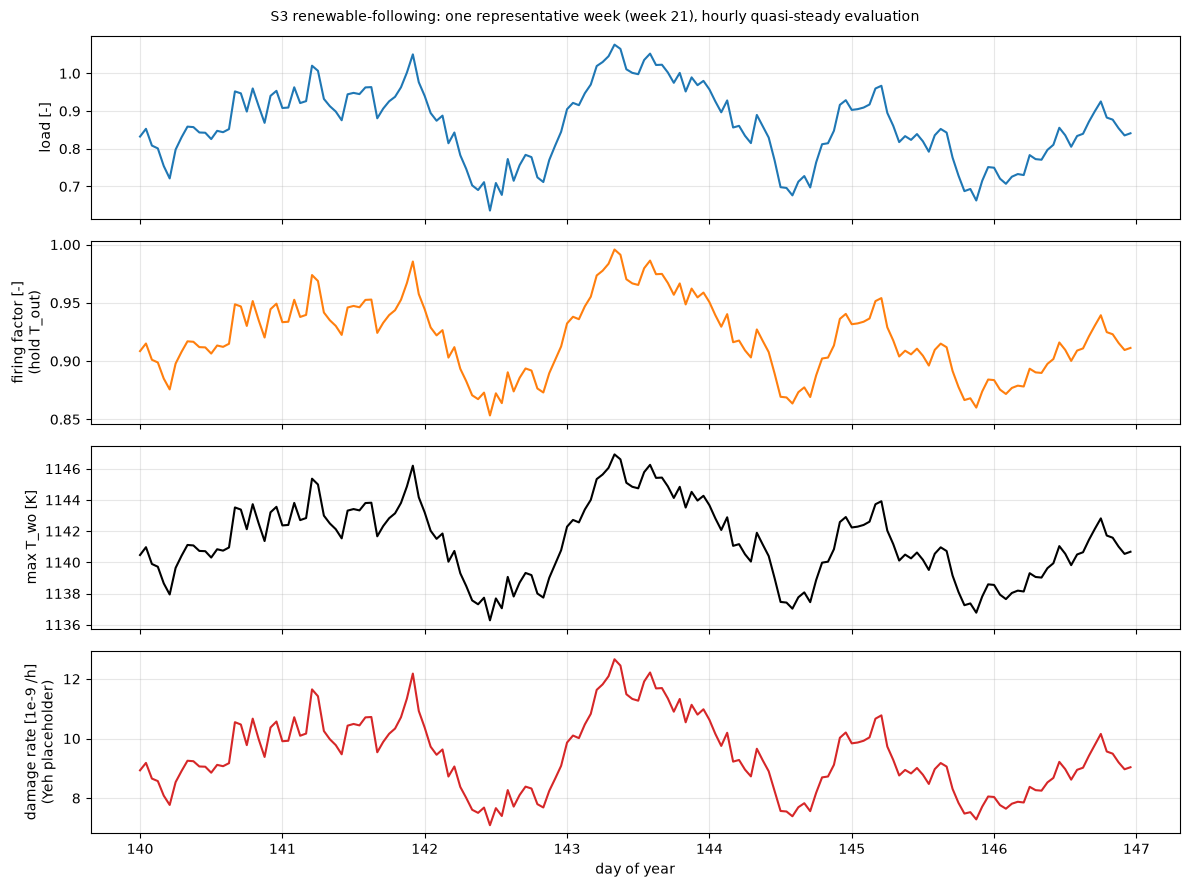

In [2]:
h3 = pd.read_csv(sc.OUT_DIR / "hourly_S3_renewable.csv.gz")
wk = slice(24 * 7 * 20, 24 * 7 * 21)   # week 21
t = np.arange(len(h3))[wk] / 24.0
fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
ax[0].plot(t, h3.feed_per_tube_fraction[wk], color="C0"); ax[0].set_ylabel("load [-]")
ax[1].plot(t, h3.specific_firing_factor[wk], color="C1"); ax[1].set_ylabel("firing factor [-]\n(hold T_out)")
ax[2].plot(t, h3.T_wo_max_K[wk], color="k"); ax[2].set_ylabel("max T_wo [K]")
ax[3].plot(t, 1e9 * h3.dD[wk], color="C3"); ax[3].set_ylabel("damage rate [1e-9 /h]\n(Yeh placeholder)"); ax[3].set_xlabel("day of year")
for a in ax: a.grid(alpha=0.3)
fig.suptitle("S3 renewable-following: one representative week (week 21), hourly quasi-steady evaluation", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig10_scenarios_timeseries.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig11_scenarios_summary.png


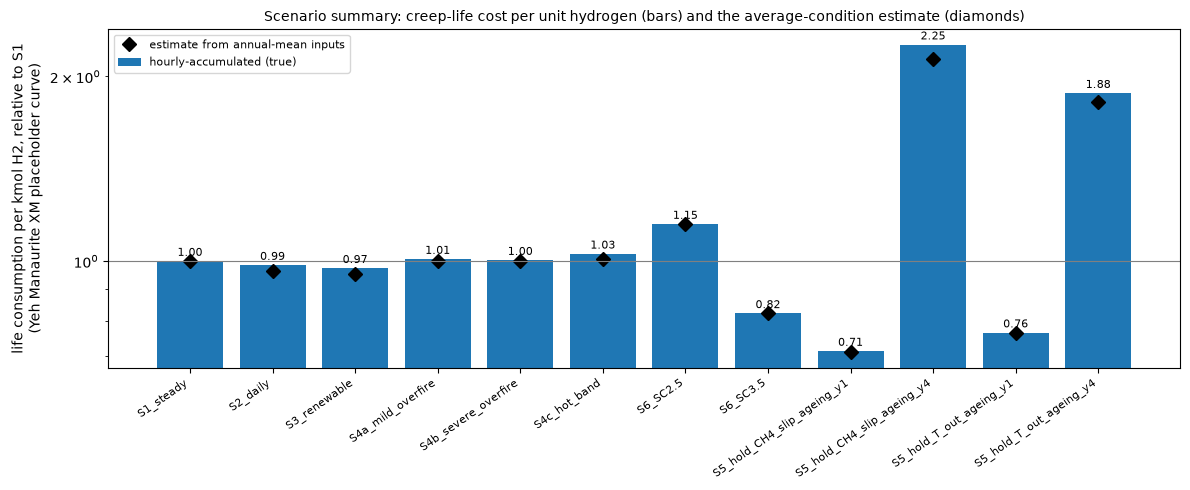

In [3]:
order = ["S1_steady", "S2_daily", "S3_renewable", "S4a_mild_overfire", "S4b_severe_overfire", "S4c_hot_band", "S6_SC2.5", "S6_SC3.5",
         "S5_hold_CH4_slip_ageing_y1", "S5_hold_CH4_slip_ageing_y4", "S5_hold_T_out_ageing_y1", "S5_hold_T_out_ageing_y4"]
order = [o for o in order if o in summ.index]
rel = summ.loc[order, "life_consumption_per_kmol_H2_rel_S1"]
D1, H1 = summ.loc["S1_steady", "annual_damage_D"], summ.loc["S1_steady", "annual_H2_kmol_per_tube"]
rel_avg = (summ.loc[order, "D_avg_condition"] / summ.loc[order, "annual_H2_kmol_per_tube"]) / (D1 / H1)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(order))
ax.bar(x, rel, color="C0", label="hourly-accumulated (true)")
ax.plot(x, rel_avg, "kD", ms=7, label="estimate from annual-mean inputs")
ax.axhline(1.0, color="grey", lw=0.8)
for i, (v, va) in enumerate(zip(rel, rel_avg)):
    ax.text(i, max(v, va) * 1.02, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("life consumption per kmol H2, relative to S1\n(Yeh Manaurite XM placeholder curve)")
ax.set_yscale("log"); ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=8)
ax.set_title("Scenario summary: creep-life cost per unit hydrogen (bars) and the average-condition estimate (diamonds)", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig11_scenarios_summary.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()
